<a href="https://colab.research.google.com/github/qjpbtuzara-ai/CPE311-CPE22S3/blob/main/Tuzara_HOA10_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Name: Tuzara, John Paul B. <br>
course and Section: CPE311-CPE22S3 <br>
Date: 4/6/26 <br>
Instructor: Engr. Neal Barton James Matira

###Instruction

1. Gather a dataset regarding your identified problem for the ASEAN Data Science Explorer. You may look at previous ADSE Competitions for Problem References. Make sure that the dataset includes multiple variables.
2. Load the dataset into pandas dataframe.
3. Prepare the data by applying appropriate data preprocessing techniques.
4. Analyze the data using descriptive analysis.
4. Perform correlation analysis.
5. Interpret the results based on the descriptive and correlation analysis.
6. Submit the PDF file and comment an accessible link.

###Extract

In [1]:
import pandas as pd

file_name = 'Index of Industrial Production for Manufacturing Industry in ASEAN.xlsx'
df = pd.read_excel(file_name)

df.head(10)

,Unnamed: 0,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6
0,Index of Industrial Production for Manufacturi...,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Indicator/Year,Indonesia,Malaysia,Philippines,Singapore,Thailand,Viet Nam
3,NaN,(2010=100),(2015=100),(2018=100),(2019=100),(2021=100),(2011=100)
4,Index,NaN,NaN,NaN,NaN,NaN,NaN
5,2012,108.380894,111.3,82.180316,83.609,82.180316,105.81
6,2013,114.88934,116,78.467874,85.007,78.467874,105.88
7,2014,120.358769,123,83.350063,87.288,83.350063,107.563876
8,2015,126.09,100.000044,78.168916,82.812,78.168916,109.761291
9,2016,131.149147,104.333228,84.092313,85.876,84.092313,107.383132


###Transform

In [10]:
df = pd.read_excel(file_name, skiprows=3) #skip 3 rows that says NaN and the year and country names

df.columns = ['Year', 'Indonesia', 'Malaysia', 'Philippines', 'Singapore', 'Thailand', 'Vietnam'] #rename columns from unnamed to the year and names

df = df[df['Year'].astype(str).str.contains(r'^\d{4}$', na=False)].copy() #rows that dont have a year date or 4 digits, are removed, store

for col in df.columns: #convert values to numeric via columns
    df[col] = pd.to_numeric(df[col], errors='coerce')

df = df.dropna() #drop missing columns

print("Data Preprocessing Complete. Cleaned data sample:")
df.head(10)


Data Preprocessing Complete. Cleaned data sample:


,Year,Indonesia,Malaysia,Philippines,Singapore,Thailand,Vietnam
2,2012,108.380894,111.300000,82.180316,83.609,82.180316,105.810000
3,2013,114.889340,116.000000,78.467874,85.007,78.467874,105.880000
4,2014,120.358769,123.000000,83.350063,87.288,83.350063,107.563876
5,2015,126.090000,100.000044,78.168916,82.812,78.168916,109.761291
6,2016,131.149147,104.333228,84.092313,85.876,84.092313,107.383132
7,2017,137.367933,110.714849,92.705627,94.813,92.705627,111.300000
8,2018,142.924651,116.005881,100.000000,101.477,100.000000,110.088805
9,2019,148.649355,120.128512,89.089043,100.000,89.089043,109.090000
10,2020,133.613277,116.939748,50.811159,107.531,50.811159,103.291031
11,2021,143.663792,128.059636,75.809356,121.837,75.809356,104.659396


###Load

              Year   Indonesia    Malaysia  Philippines   Singapore  \
count    21.000000   21.000000   21.000000    21.000000   21.000000   
mean   2017.238095   70.964480   62.396781    45.074050   53.229428   
std       3.112953   66.826487   59.228339    44.200988   49.177805   
min    2012.000000  -10.115131  -18.699151   -42.965872   -5.127853   
25%    2015.000000    4.741767    4.778972     7.577689    3.699947   
50%    2017.000000  108.380894  100.000044    50.811159   82.812000   
75%    2020.000000  133.613277  116.005881    83.350063   94.813000   
max    2022.000000  149.420617  138.501382   100.000000  125.126000   

         Thailand     Vietnam  
count   21.000000   21.000000  
mean    45.073569   56.385838  
std     44.200899   54.965560  
min    -42.965872   -5.315765  
25%      7.577689    1.324766  
50%     50.811159  103.291031  
75%     83.350063  107.432044  
max    100.000000  111.300000  


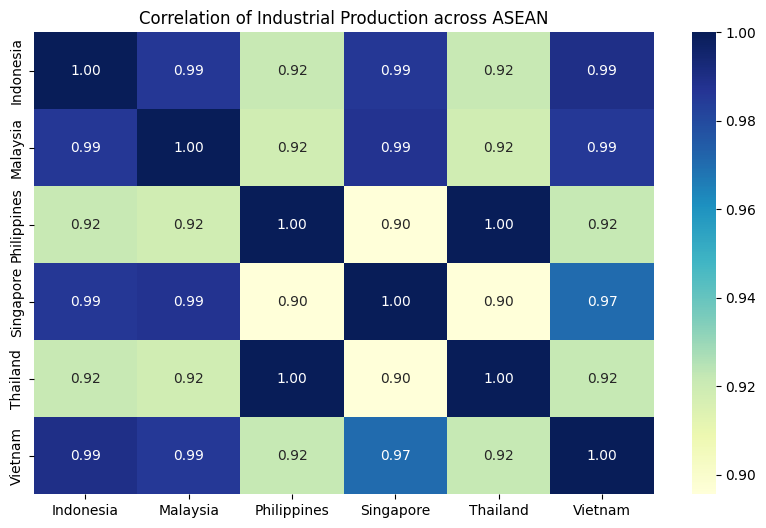

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

print(df.describe()) #show statistics

correlation_matrix = df.drop(columns = ['Year']).corr() #correlation matrix excluding year

plt.figure(figsize=(10,6))
sns.heatmap(correlation_matrix, annot=True, cmap = 'YlGnBu', fmt='.2f')  #yellow green blue, to 2 decimal places
plt.title('Correlation of Industrial Production across ASEAN')
plt.show()

###Interpretation/Data Analysis

I see that Indonesia among ASEAN countries has the most mean production, meanwhile our country the philippines produced the lowest average. Indonesia has the overall highest standard deviation, which means that their production has been relatively stable and high. Manwhile countries like Malaysia and Vietnam surpass the more stable and richer country like singapore in this aspect, suggesting that they have been having rapid industrial growth and change for the past 3 years in ASEAN.

All the countries in ASEAN have stroing trade links as the graph shows a strong +0.9 correlation. Although there are stronger relations to the productions suggesting a sync in their production. Indonesia for example is highly in sync with not just its neighbors, Malaysia and Singapore but also Vietnam. Malaysia having similar synchronization with Indonesia, Singapore and Vietnam as well. Singapore and Vietnam having similar as well but Singapore having less trade with vietnam and Vietnam having less trade with Singapore. However, the case for the Philippines and Thailand is different as they are almost perfectly in sync with their production as it is 1.00 among other countries. It seems that both countries focus on their trade synchronicity more in recent years than the other ASEAN countries. Overall, the correlation suggests that ASEAN countries have still a long way to go from its goal of economic regional synchronization.


###Conclusion

In this activity I have fetched a dataset from the ASEAN Stats Data Portal for the ASEAN Data Science Explorers or ADSE Competition, chose an indicator data set and then performed ETL and then EDA on it. I first extracted the dataset I got which is given to me as an excel file in which I have displayed using Pandas. Using Pandas as well, I am able to perform the Transform part by skipping the rows that includes the columns in the excel file and then labelling the columns as they are unnamed. I then loaded the data using Matplotlib.pyplot and Seaborn, for which I made a correlational heatmap with the. heatmap() without the year column as well as Pandas' .describe() function.In which case I have interpreted and analyzed that Indonesia as a steady manufacturing giant of ASEAN as well as Vietnam having steady growth and trade over the recent years which can also be seen with the heatmap that vietnam having stronger production sync with Indonesia, Malaysia and Singapore. Meanwhile the Philippines and Thailand have focused their synchronicity in production trade over the recent years. I've also seen some limitations from the website as Myanmar and Laos seems to have no data due to the instability facing either their economic and political situations. I primarily chose this indicator to not see how our country the Philippines performs in terms of pride but to see where my country lacks in this particular area, in addressing the issue and reinforcing the benefits.